<a href="https://colab.research.google.com/github/PURNACHANDRARAOPARCHURI/crop-disease-prediction-system/blob/main/crop_reccomendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import kagglehub
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")

Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.


In [4]:
import os
for root,dirs,files in os.walk(path):
  if "train" in dirs:
    train_dir=os.path.join(root,"train")
    print(train_dir)
    break



/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train


Class: Tomato___Late_blight
Image: 781e93a9-2059-42de-8075-658033a6abf7___RS_Late.B 6075.JPG


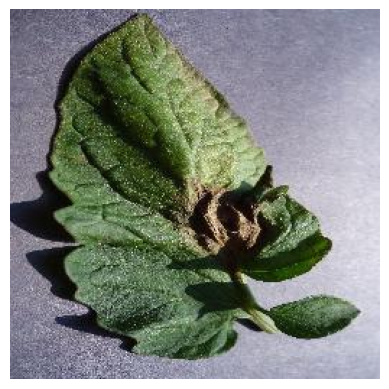

In [5]:
import os
from PIL import Image
import matplotlib.pyplot as plt
class_name = os.listdir(train_dir)[0]
img_name = os.listdir(os.path.join(train_dir, class_name))[0]
img_path = os.path.join(train_dir, class_name, img_name)
print("Class:", class_name)
print("Image:", img_name)
img = Image.open(img_path)
plt.imshow(img)
plt.axis("off")
plt.show()

In [6]:
img.size
tf.keras.utils.image_dataset_from_directory?

In [7]:
import os
import random
import shutil
source_dir = train_dir
target_dir1 = "/kaggle/working/train_1000"
os.makedirs(target_dir1, exist_ok=True)
for class_name in os.listdir(source_dir):
    class_path = os.path.join(source_dir, class_name)
    if not os.path.isdir(class_path):
        continue
    target_class_path = os.path.join(target_dir1, class_name)
    os.makedirs(target_class_path, exist_ok=True)
    images = os.listdir(class_path)
    selected_images = random.sample(
        images,
        min(1000, len(images))
    )

    for img in selected_images:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(target_class_path, img)
        )

    print(f"{class_name}: {len(selected_images)} images copied")

print("Dataset creation completed!")

Tomato___Late_blight: 1000 images copied
Tomato___healthy: 1000 images copied
Grape___healthy: 1000 images copied
Orange___Haunglongbing_(Citrus_greening): 1000 images copied
Soybean___healthy: 1000 images copied
Squash___Powdery_mildew: 1000 images copied
Potato___healthy: 1000 images copied
Corn_(maize)___Northern_Leaf_Blight: 1000 images copied
Tomato___Early_blight: 1000 images copied
Tomato___Septoria_leaf_spot: 1000 images copied
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 1000 images copied
Strawberry___Leaf_scorch: 1000 images copied
Peach___healthy: 1000 images copied
Apple___Apple_scab: 1000 images copied
Tomato___Tomato_Yellow_Leaf_Curl_Virus: 1000 images copied
Tomato___Bacterial_spot: 1000 images copied
Apple___Black_rot: 1000 images copied
Blueberry___healthy: 1000 images copied
Cherry_(including_sour)___Powdery_mildew: 1000 images copied
Peach___Bacterial_spot: 1000 images copied
Apple___Cedar_apple_rust: 1000 images copied
Tomato___Target_Spot: 1000 images copie

In [8]:
import tensorflow as tf
training_set=tf.keras.utils.image_dataset_from_directory(
    target_dir1,labels="inferred",label_mode="categorical",image_size=(300,300),color_mode="rgb",shuffle=True,validation_split=None,verbose=True
    ,interpolation="bilinear",batch_size=32
)

Found 38000 files belonging to 38 classes.


In [9]:
for root,dirs,files in os.walk(path):
  if "valid" in dirs:
    valid_dir=os.path.join(root,"valid")
    print(valid_dir)
    break

/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid


In [10]:
import os
import random
import shutil

source_dir = valid_dir
target_dir2 = "/kaggle/working/valid_200"

os.makedirs(target_dir2, exist_ok=True)
for class_name in os.listdir(source_dir):
    class_path = os.path.join(source_dir, class_name)
    if not os.path.isdir(class_path):
        continue
    target_class_path = os.path.join(target_dir2, class_name)
    os.makedirs(target_class_path, exist_ok=True)
    images = os.listdir(class_path)
    selected_images = random.sample(
        images,
        min(200, len(images))
    )
    for img in selected_images:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(target_class_path, img)
        )
    print(f"{class_name}: {len(selected_images)} images copied")
print("Validation dataset created!")

Tomato___Late_blight: 200 images copied
Tomato___healthy: 200 images copied
Grape___healthy: 200 images copied
Orange___Haunglongbing_(Citrus_greening): 200 images copied
Soybean___healthy: 200 images copied
Squash___Powdery_mildew: 200 images copied
Potato___healthy: 200 images copied
Corn_(maize)___Northern_Leaf_Blight: 200 images copied
Tomato___Early_blight: 200 images copied
Tomato___Septoria_leaf_spot: 200 images copied
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 200 images copied
Strawberry___Leaf_scorch: 200 images copied
Peach___healthy: 200 images copied
Apple___Apple_scab: 200 images copied
Tomato___Tomato_Yellow_Leaf_Curl_Virus: 200 images copied
Tomato___Bacterial_spot: 200 images copied
Apple___Black_rot: 200 images copied
Blueberry___healthy: 200 images copied
Cherry_(including_sour)___Powdery_mildew: 200 images copied
Peach___Bacterial_spot: 200 images copied
Apple___Cedar_apple_rust: 200 images copied
Tomato___Target_Spot: 200 images copied
Pepper,_bell___healt

In [11]:
validation_set=tf.keras.utils.image_dataset_from_directory(
    target_dir2,labels="inferred",label_mode="categorical",image_size=(300,300),color_mode="rgb",shuffle=True,validation_split=None,verbose=True,interpolation="bilinear",batch_size=32
)

Found 7600 files belonging to 38 classes.


In [12]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

In [13]:
from tensorflow.keras.applications import EfficientNetB3
base_model=EfficientNetB3(
    input_shape=(300,300,3),
    include_top=False,
    weights="imagenet"

)

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [14]:
from tensorflow.keras.layers import GlobalAveragePooling2D,Dropout,Dense
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
output = Dense(38, activation='softmax')(x)

In [15]:
from tensorflow.keras.models import Model
model = Model(
    inputs=base_model.input,
    outputs=output
)

In [16]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 300, 300,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 300, 300,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 300, 300,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 301, 301,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 150, 150,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 150, 150,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 150, 150,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 150, 150,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 150, 150,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 150, 150,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 150, 150,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 150, 150,  │        960 │ block1a_se_excit

 Total params: 10,841,941 (41.36 MB)

 Trainable params: 10,754,638 (41.03 MB)

 Non-trainable params: 87,303 (341.03 KB)

In [18]:
training_history = model.fit(
    training_set,
    validation_data=validation_set,
    epochs=4
)

Epoch 1/4
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 783s 539ms/step - accuracy: 0.9178 - loss: 0.3700 - val_accuracy: 0.9903 - val_loss: 0.0327
Epoch 2/4
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 536s 451ms/step - accuracy: 0.9921 - loss: 0.0306 - val_accuracy: 0.9951 - val_loss: 0.0159
Epoch 3/4
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 535s 450ms/step - accuracy: 0.9947 - loss: 0.0190 - val_accuracy: 0.9961 - val_loss: 0.0125
Epoch 4/4
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 563s 451ms/step - accuracy: 0.9956 - loss: 0.0156 - val_accuracy: 0.9947 - val_loss: 0.0197


238/238 ━━━━━━━━━━━━━━━━━━━━ 27s 113ms/step - accuracy: 0.9947 - loss: 0.0197
Validation Loss: 0.0197
Validation Accuracy: 99.47%


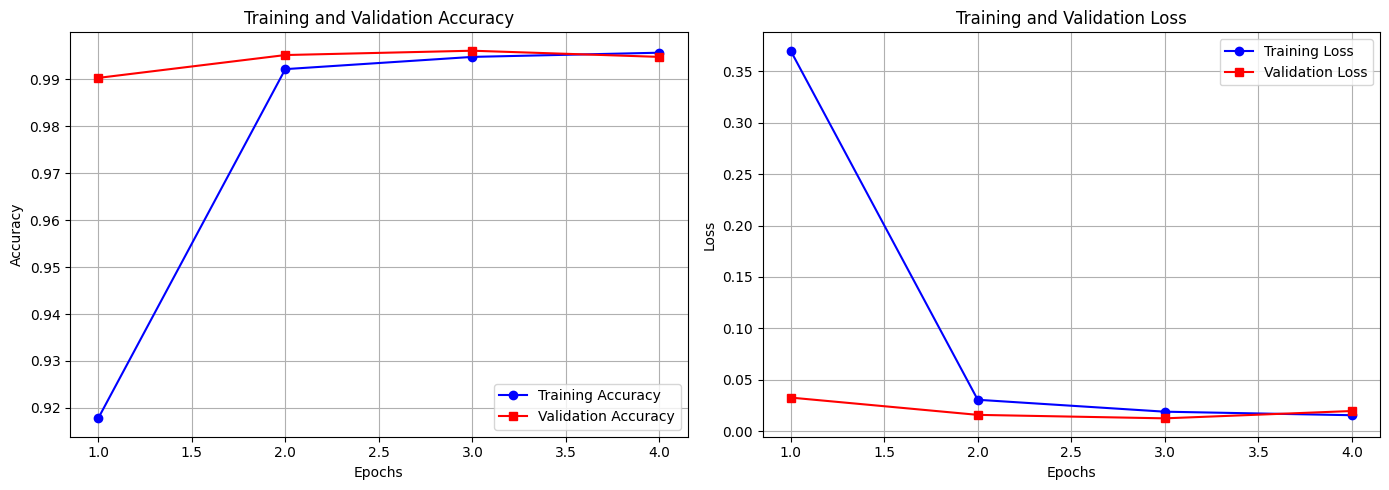

Model saved successfully as 'crop_disease_prediction_model.keras'!


In [23]:
import matplotlib.pyplot as plt
val_loss, val_acc = model.evaluate(validation_set)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc * 100:.2f}%")
epochs = range(1, len(training_history.history['accuracy']) + 1)
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, training_history.history['accuracy'], 'b-o', label='Training Accuracy')
plt.plot(epochs, training_history.history['val_accuracy'], 'r-s', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(epochs, training_history.history['loss'], 'b-o', label='Training Loss')
plt.plot(epochs, training_history.history['val_loss'], 'r-s', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
model.save('crop_disease_prediction_model.keras')
print("Model saved successfully as 'crop_disease_prediction_model.keras'!")